# Zomato Bangalore - What Makes a Restaurant Great? 🍽️

## The Question
What really determines a restaurant's rating in Bangalore?
Is it the price? The location? Online delivery?

## Dataset
- 51,717 restaurants from Bangalore
- Source: Zomato via Kaggle

## What I Found

### 1. Online Order vs Rating
Restaurants with online ordering have slightly better ratings (3.72) 
vs those without (3.65). 
Why? Online customers focus on food quality, not ambience.

### 2. Cost vs Rating
| Category | Avg Cost | Avg Rating |
|----------|----------|------------|
| Budget | ₹40 - ₹300 | 3.57 |
| Mid-range | ₹300 - ₹700 | 3.63 |
| Premium | ₹700+ | 3.99 |

Money matters — premium restaurants rate significantly better.

### 3. Top Locations
Lavelle Road, Koramangala & Church Street dominate —
all upscale South Bangalore areas.

### 4. Rating Distribution
Most restaurants cluster between 3.5 - 4.0.
A perfect 5.0 rating practically doesn't exist.

## Key Insight
> "In Bangalore, a restaurant's rating isn't just about food —
> it's about price, location and convenience combined."

## Tools Used
Python • Pandas • Matplotlib • Seaborn

In [1]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/himanshupoddar/zomato-bangalore-restaurants/zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [2]:
print(df.shape)
print(df.columns.tolist())

(51717, 17)
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


In [3]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [4]:
df_clean = df.dropna(subset=['rate'])
print(df_clean.shape)

(43942, 17)


In [5]:
df_clean['rate'] = df_clean['rate'].str.split('/').str[0]
df_clean['rate'] = pd.to_numeric(df_clean['rate'], errors='coerce')
df_clean = df_clean.dropna(subset=['rate'])
print(df_clean['rate'].describe())

count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64


/tmp/ipykernel_17/3366200566.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['rate'] = df_clean['rate'].str.split('/').str[0]
/tmp/ipykernel_17/3366200566.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['rate'] = pd.to_numeric(df_clean['rate'], errors='coerce')


In [6]:
print(df_clean.groupby('online_order')['rate'].mean())

online_order
No     3.65907
Yes    3.72244
Name: rate, dtype: float64


In [7]:
df_clean['cost'] = df_clean['approx_cost(for two people)'].str.replace(',','').astype(float)
print(df_clean['cost'].describe())

count    41418.000000
mean       603.268048
std        464.327857
min         40.000000
25%        300.000000
50%        500.000000
75%        700.000000
max       6000.000000
Name: cost, dtype: float64


In [8]:
df_clean['cost_category'] = pd.cut(df_clean['cost'], 
                                    bins=[0, 300, 700, 6000], 
                                    labels=['Budget', 'Mid-range', 'Premium'])

print(df_clean.groupby('cost_category')['rate'].mean())

cost_category
Budget       3.567165
Mid-range    3.629048
Premium      3.989615
Name: rate, dtype: float64


/tmp/ipykernel_17/2623260859.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby('cost_category')['rate'].mean())


In [9]:
top_locations = df_clean.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)
print(top_locations)

location
Lavelle Road             4.142505
Koramangala 3rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5th Block    4.005821
Church Street            3.992125
Sankey Road              3.965385
Koramangala 4th Block    3.918668
Cunningham Road          3.901053
Residency Road           3.863636
MG Road                  3.855857
Name: rate, dtype: float64


In [10]:
import subprocess
subprocess.run(['pip', 'install', 'matplotlib', '--quiet'])
import matplotlib.pyplot as plt
import seaborn as sns
print("Done!")

Done!


/tmp/ipykernel_17/890224474.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('cost_category')['rate'].mean().plot(


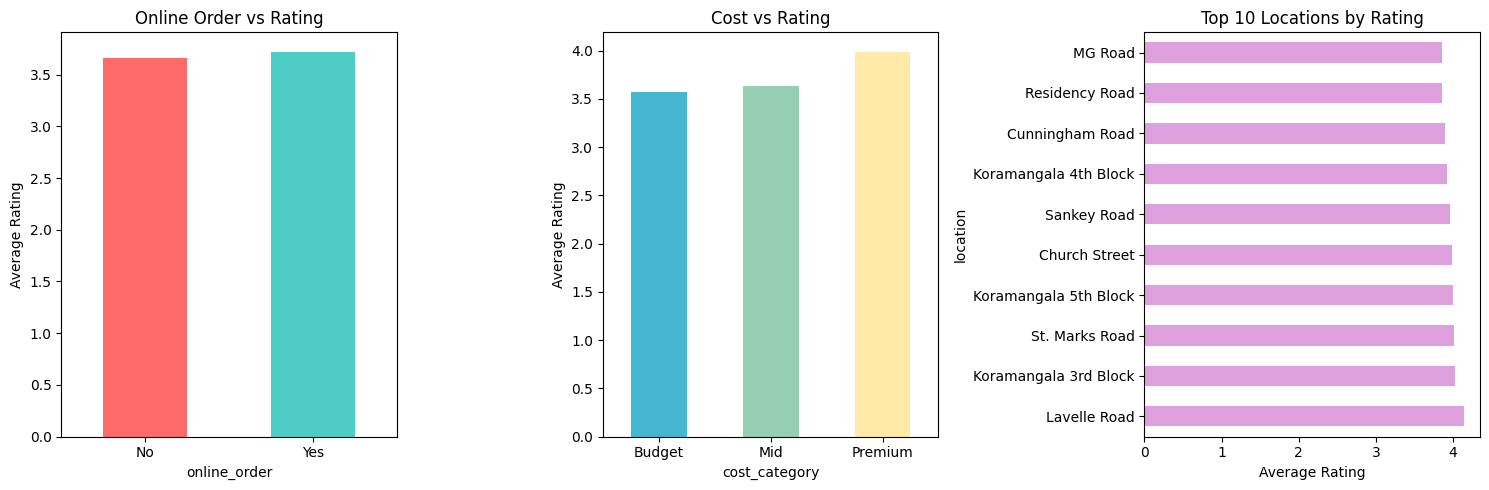

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Graph 1: Online Order vs Rating
df_clean.groupby('online_order')['rate'].mean().plot(
    kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Online Order vs Rating')
axes[0].set_ylabel('Average Rating')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Graph 2: Cost Category vs Rating
df_clean.groupby('cost_category')['rate'].mean().plot(
    kind='bar', ax=axes[1], color=['#45B7D1', '#96CEB4', '#FFEAA7'])
axes[1].set_title('Cost vs Rating')
axes[1].set_ylabel('Average Rating')
axes[1].set_xticklabels(['Budget', 'Mid', 'Premium'], rotation=0)

# Graph 3: Top 10 Locations
top_locations.plot(
    kind='barh', ax=axes[2], color='#DDA0DD')
axes[2].set_title('Top 10 Locations by Rating')
axes[2].set_xlabel('Average Rating')

plt.tight_layout()
plt.show()

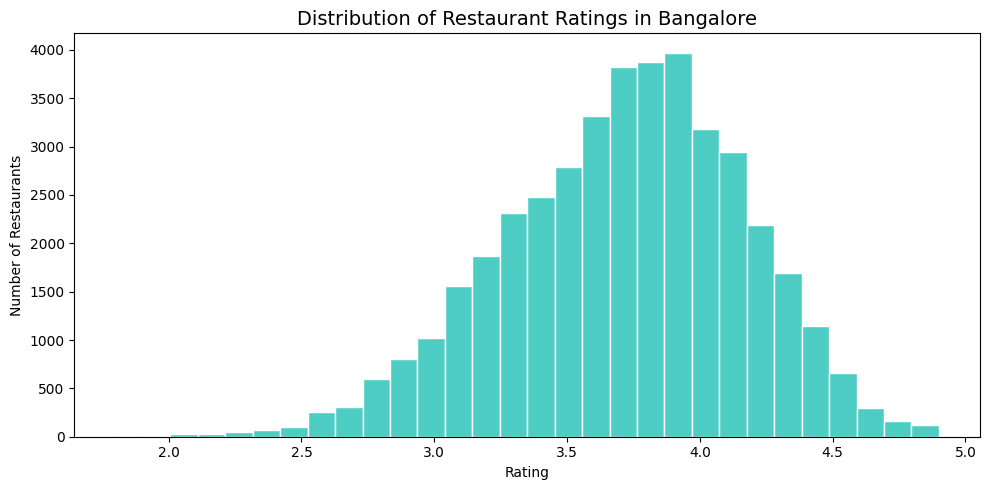

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
df_clean['rate'].dropna().plot(kind='hist', bins=30, color='#4ECDC4', edgecolor='white', ax=ax)
ax.set_title('Distribution of Restaurant Ratings in Bangalore', fontsize=14)
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()